# Importations

In [40]:
#!pip install wordcloud
#!python -m spacy download fr_core_news_sm

In [41]:
from glob import glob
import re
import nltk
from nltk.corpus import stopwords as sw
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from wordcloud import WordCloud
from sklearn.metrics.pairwise import cosine_similarity
import spacy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [42]:
nltk.download("stopwords")
sw = set(sw.words("french"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Marc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Fonctions

In [43]:
def lire(txt):
    with open(txt, "r", encoding="utf-8") as f:
        return f.read()

def clean(txt):
    txt = txt.lower()
    txt = txt.replace("_", " ")
    txt = re.sub(r"[^\w\s]", " ", txt)
    txt = re.sub(r"\s+", " ", txt)
    return txt.strip()

def mots(txt):
    mots = txt.split(" ")
    return mots

def lexique(mots):
    lexique = {}
    for m in mots:
        if m in lexique:
            lexique[m] += 1
        else:
            lexique[m] = 1
    lexique = sorted(lexique.items(), key=lambda x: x[1], reverse=True)
    return lexique

def stopwords(mots):
    filtre = [m for m in mots if m not in sw]
    return filtre

# MAIN

# 1. Prétraitement et fréquences

In [44]:
hugo = clean(lire("corpus//Hugo_NotreDameDeParis.txt"))
zola = clean(lire("corpus//Zola_Germinal.txt"))

mots_hugo = mots(hugo)
mots_zola = mots(zola)
compte_hugo = len(mots_hugo)
compte_zola = len(mots_zola)

In [45]:
lex_hugo = lexique(mots_hugo)
lex_zola = lexique(mots_zola)
print(lex_hugo[:10])
print(lex_zola[:10])

[('de', 8463), ('la', 5521), ('et', 4663), ('le', 4217), ('l', 3573), ('à', 3561), ('il', 3038), ('un', 2647), ('les', 2521), ('d', 2263)]
[('de', 7257), ('la', 5678), ('les', 3979), ('le', 3938), ('il', 3828), ('et', 3173), ('à', 2874), ('l', 2636), ('un', 2509), ('d', 2435)]


In [46]:
sw_hugo = stopwords(mots_hugo)
sw_zola = stopwords(mots_zola)
lex_sw_hugo = lexique(sw_hugo)
lex_sw_zola = lexique(sw_zola)

print(lex_sw_hugo[:30])
print("___________")
print(lex_sw_zola[:30])

[('plus', 900), ('cette', 815), ('tout', 751), ('dit', 721), ('comme', 716), ('a', 638), ('si', 536), ('deux', 453), ('où', 383), ('bien', 380), ('là', 344), ('sans', 344), ('gringoire', 336), ('fait', 318), ('cela', 311), ('roi', 304), ('tête', 292), ('encore', 287), ('paris', 280), ('fille', 276), ('sous', 274), ('être', 262), ('dont', 257), ('autre', 257), ('quasimodo', 248), ('moment', 246), ('homme', 241), ('tous', 240), ('maître', 237), ('toutes', 237)]
___________
[('plus', 708), ('si', 611), ('comme', 593), ('sans', 555), ('cette', 511), ('étienne', 500), ('deux', 498), ('tout', 481), ('a', 461), ('là', 413), ('ça', 383), ('où', 362), ('encore', 354), ('sous', 350), ('bien', 345), ('être', 331), ('puis', 322), ('tous', 303), ('dont', 283), ('quand', 283), ('autre', 271), ('maheu', 266), ('homme', 259), ('air', 257), ('dit', 251), ('catherine', 233), ('toujours', 232), ('avoir', 231), ('donc', 231), ('autres', 225)]


# 2. TF-IDF

In [47]:
docs = [hugo, zola]
labels = ["hugo", "zola"]

vect = TfidfVectorizer(stop_words=list(sw), max_features=2000)
X = vect.fit_transform(docs)

feat = vect.get_feature_names_out()

In [48]:
def top_mots(row, feat, n=15):
    s = row.toarray().flatten()
    idx = np.argsort(s)[::-1][:n]
    return [(feat[i], s[i]) for i in idx]

top_hugo = top_mots(X[0], feat)
top_zola = top_mots(X[1], feat)

print("Hugo :", top_hugo)
print("\nZola :", top_zola)

Hugo : [('plus', np.float64(0.2823653251557419)), ('cette', np.float64(0.25569748889103294)), ('tout', np.float64(0.23561817687995798)), ('dit', np.float64(0.22620599937476657)), ('comme', np.float64(0.22463730312390134)), ('si', np.float64(0.16816423809275297)), ('gringoire', np.float64(0.14815905523851106)), ('deux', np.float64(0.1421238803283901)), ('où', np.float64(0.12016213281627683)), ('bien', np.float64(0.11922091506575769)), ('quasimodo', np.float64(0.10935549315223435)), ('sans', np.float64(0.10792630205952802)), ('là', np.float64(0.10792630205952802)), ('fait', np.float64(0.09976908155502881)), ('cela', np.float64(0.09757290680381749))]

Zola : [('plus', np.float64(0.240222545448179)), ('si', np.float64(0.20731069953225617)), ('comme', np.float64(0.20120334668187875)), ('sans', np.float64(0.18831004621997083)), ('cette', np.float64(0.17338096147460377)), ('étienne', np.float64(0.16964869028826202)), ('deux', np.float64(0.16897009552710895)), ('tout', np.float64(0.16320204005

# 3. Visualisation

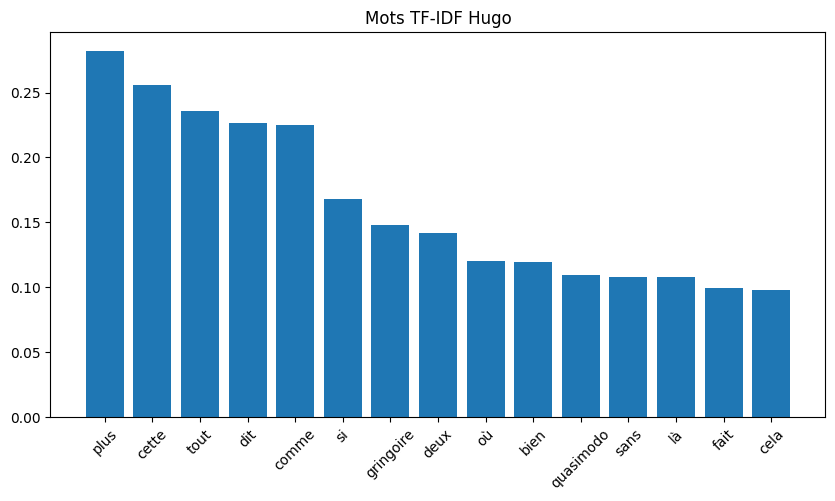

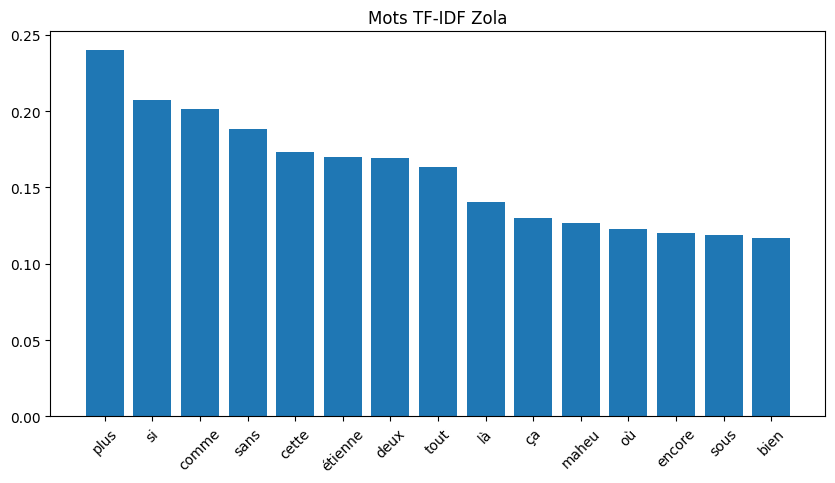

In [49]:
def bar_mots(mots, titre):
    mots, val = zip(*mots)

    plt.figure(figsize=(10,5))
    plt.bar(mots, val)
    plt.xticks(rotation=45)
    plt.title(titre)
    plt.show()

bar_mots(top_hugo, "Mots TF-IDF Hugo")
bar_mots(top_zola, "Mots TF-IDF Zola")

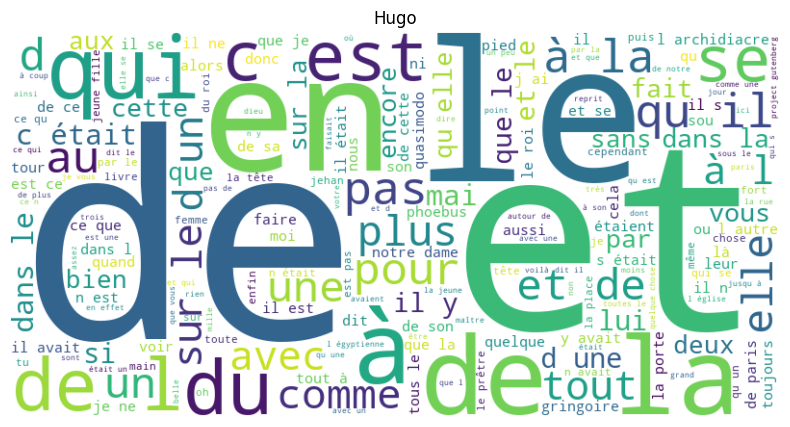

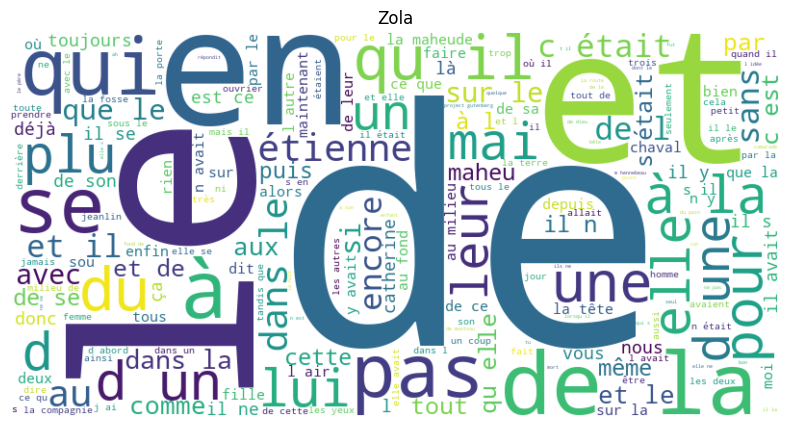

In [50]:
def nuage(txt, titre):
    wc = WordCloud(width=800, height=400, background_color="white").generate(txt)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(titre)
    plt.show()

nuage(hugo, "Hugo")
nuage(zola, "Zola")

# 4. Classification

In [51]:
def chunk(txt, n=5000):
    return [txt[i:i+n] for i in range(0, len(txt), n)]

hugo_chunks = chunk(hugo)
zola_chunks = chunk(zola)

X_txt = hugo_chunks + zola_chunks
y = ["hugo"] * len(hugo_chunks) + ["zola"] * len(zola_chunks)
X = vect.transform(X_txt)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

mod = LogisticRegression(max_iter=1000)
mod.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [53]:
y_pred = mod.predict(X_test)

print("Score :", mod.score(X_test, y_test))
print(classification_report(y_test, y_pred))

Score : 0.9753086419753086
              precision    recall  f1-score   support

        hugo       0.98      0.98      0.98        41
        zola       0.97      0.97      0.97        40

    accuracy                           0.98        81
   macro avg       0.98      0.98      0.98        81
weighted avg       0.98      0.98      0.98        81

